In [15]:
# import sys
# sys.path.append("..")

# from eda_utils import plot_scatter
from eda_mod import *

df = load_data("../data/ethiopia.csv")
df = clean_missing(df)
df["Country"]="ethiopia"
# df["DATE"] =pd.to_datetime(df["YEAR"].astype(str) + df["DOY"].astype(str), format="%Y%j")
df["DATE"] = pd.to_datetime(
    df["YEAR"].astype(str) + df["DOY"].astype(str).str.zfill(3),
    format="%Y%j"
)
# df["DATE"].dtype
df["MONTH"]=df["DATE"].dt.month
df.describe()

No missing values found.


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [16]:
#summary stats & missing_value report
df=df.replace(-999,np.nan)
df.duplicated().sum()
df.describe()
# Run df.describe() on all numeric columns and write a brief interpretation in a markdown cell below the output.

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


There are 0 duplicate rows from all the columns.


In [17]:
#compute the percentage of missing values per column
df.isna().sum()
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isnull().sum()/(len(df)))*100
})
# print(missing_summary)
high_missing = missing_summary[missing_summary['missing_percent'] > 5]
print(high_missing)

Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []


In [18]:
#Outlier Detection & Basic Cleaning
# df.describe(include='all').T
# # print(df.dtypes)
# numeric_df = df.select_dtypes(include=[np.number])
# z_scores = np.abs(stats.zscore(numeric_df))
# print(z_scores)


# ##z_score
# cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
# subset = df[cols]
# z_scores = np.abs(stats.zscore(subset))
# print(z_scores)
# outliers = (z_scores > 3).any(axis=1)
# outlier_count = outliers.sum()
# print(outlier_count)
# outlier_percentage = (outlier_count / len(df)) * 100
# print(outlier_percentage)


from scipy.stats import zscore
import numpy as np

cols = ["T2M", "T2M_MAX", "T2M_MIN",
        "PRECTOTCORR", "RH2M",
        "WS2M", "WS2M_MAX"]

# Compute Z-scores for all selected columns
z_scores = df[cols].apply(zscore)
# Flag rows where any |Z| > 3
outliers = (np.abs(z_scores) > 3).any(axis=1)
# Count flagged rows
outlier_count = outliers.sum()
print("Number of outlier rows:", outlier_count)


#Decide whether to drop, cap, or retain outlier rows
df[["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]].skew()
df[["PRECTOTCORR", "WS2M_MAX"]].describe()
#capping
for col in ["PRECTOTCORR"]:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

z_scores = df[cols].apply(zscore)
# Flag rows where any |Z| > 3
outliers = (np.abs(z_scores) > 3).any(axis=1)
# Count flagged rows
outlier_count = outliers.sum()
print("Number of outlier rows:", outlier_count)


Number of outlier rows: 132
Number of outlier rows: 152


After applying quantile-based capping, the spread of PRECTOTCORR decreased, leading to a reduced standard deviation. Since Z-scores are standardized by standard deviation, this change altered the relative scaling of values, causing some observations to appear more extreme in standardized terms despite the removal of absolute extremes.

In [19]:
#Export the cleaned DataFrame
#df.to_csv("../data/ethiopia_clean.csv", index=False)

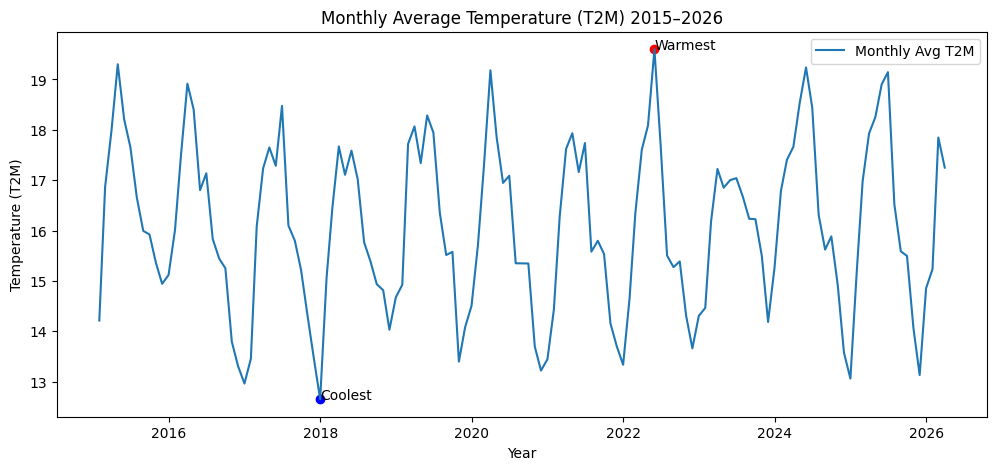

In [20]:
#Time Series Analysis


# set index for resampling
df_monthly = df.set_index('DATE').resample('ME')['T2M'].mean()

warmest_month = df_monthly.idxmax()
coolest_month = df_monthly.idxmin()

warmest_value = df_monthly.max()
coolest_value = df_monthly.min()
#visualization

plt.figure(figsize=(12,5))

plt.plot(df_monthly.index, df_monthly, label="Monthly Avg T2M")

# annotate warmest month
plt.scatter(warmest_month, warmest_value, color='red')
plt.text(warmest_month, warmest_value, "Warmest", fontsize=10, ha='left')


# annotate coolest month
plt.scatter(coolest_month, coolest_value, color='blue')
plt.text(coolest_month, coolest_value, "Coolest", fontsize=10, ha='left')

plt.title("Monthly Average Temperature (T2M) 2015–2026")
plt.xlabel("Year")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()

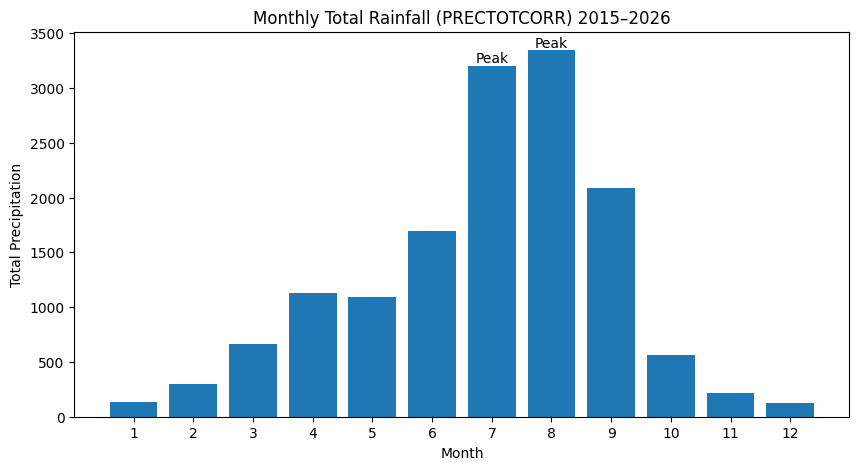

In [21]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()
peak_months = monthly_rain.sort_values(ascending=False).head(2)

# peak_months
#Plot monthly total PRECTOTCORR as a bar chart.

plt.figure(figsize=(10,5))

bars = plt.bar(monthly_rain.index, monthly_rain.to_numpy())

plt.title("Monthly Total Rainfall (PRECTOTCORR) 2015–2026")
plt.xlabel("Month")
plt.ylabel("Total Precipitation")

# annotate peak rainy months
for month, value in peak_months.items():
    plt.text(month, value, "Peak", ha='center', va='bottom', fontsize=10)

plt.xticks(range(1,13))
plt.show()

Some months show unusually high rainfall spikes compared to adjacent years, which may indicate extreme weather events or outliers.
Overall, the dataset reflects a stable and predictable seasonal precipitation regime, with limited anomalies and strong consistency in wet vs dry season behavior.

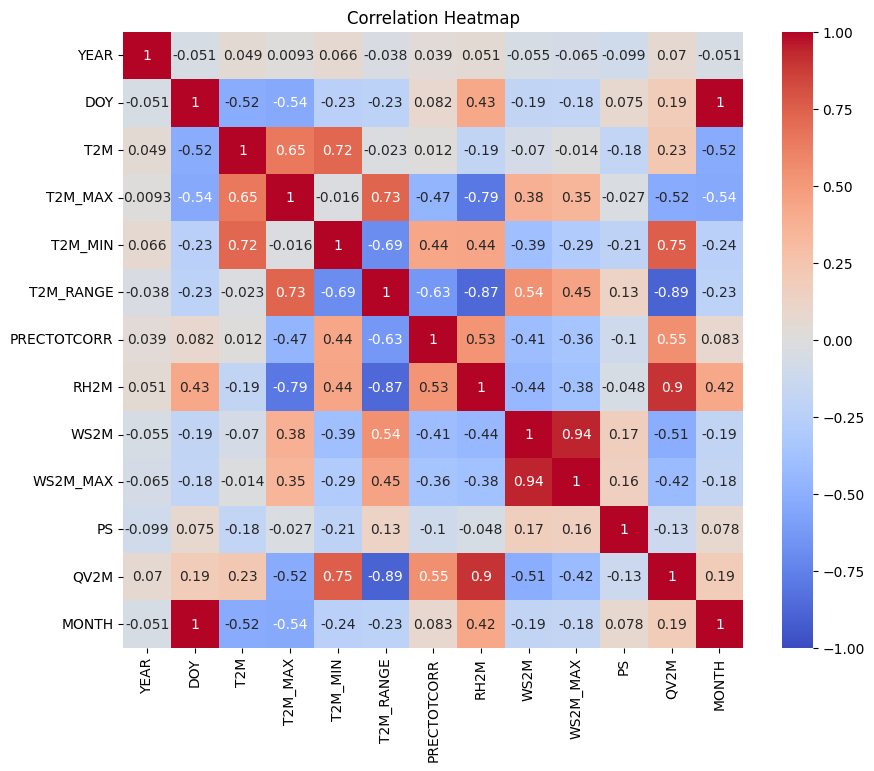

In [22]:
#Correlation & Relationship Analysis
corr = df.select_dtypes(include=np.number).corr()

import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

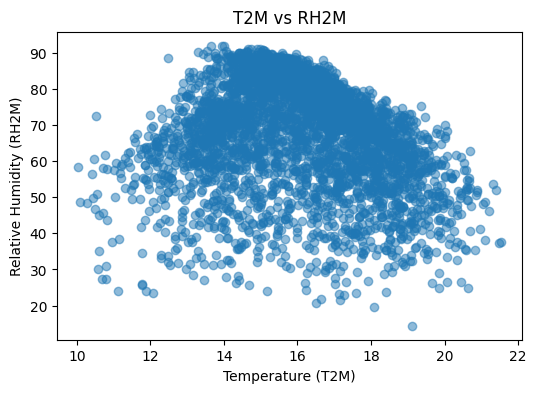

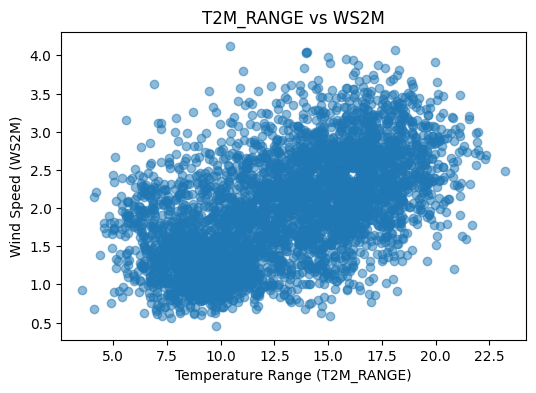

In [23]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)

plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.show()
plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)

plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.show()
# cleaning
# plt.scatter(df["T2M"], df["RH2M"], s=10, alpha=0.3)

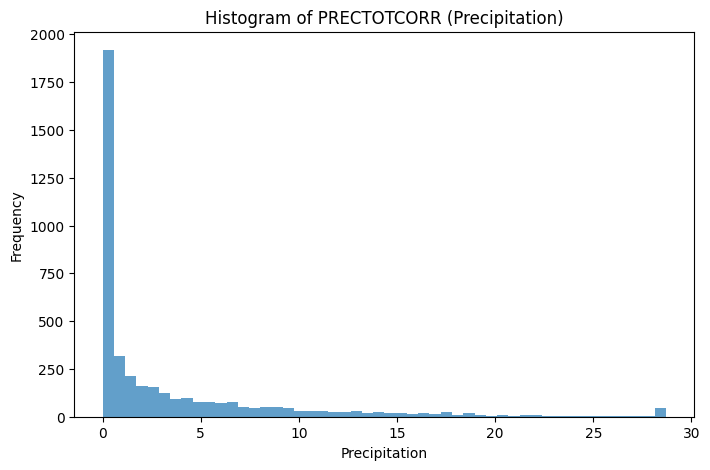

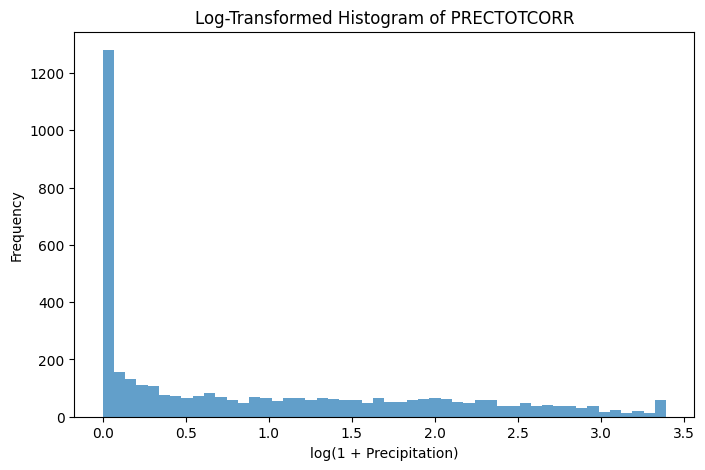

In [24]:
#Distribution Analysis

plt.figure(figsize=(8,5))

plt.hist(df["PRECTOTCORR"], bins=50, alpha=0.7)

plt.title("Histogram of PRECTOTCORR (Precipitation)")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")

plt.show()

plt.figure(figsize=(8,5))

plt.hist(np.log1p(df["PRECTOTCORR"]), bins=50, alpha=0.7)

plt.title("Log-Transformed Histogram of PRECTOTCORR")
plt.xlabel("log(1 + Precipitation)")
plt.ylabel("Frequency")

plt.show()

The distribution of precipitation (PRECTOTCORR) is strongly right-skewed, with most observations clustered near zero and a long tail extending toward higher values.
After Log Transformation
Applying a log scale (log(1 + PRECTOTCORR)) compresses extreme values.
The distribution becomes more balanced and easier to interpret.

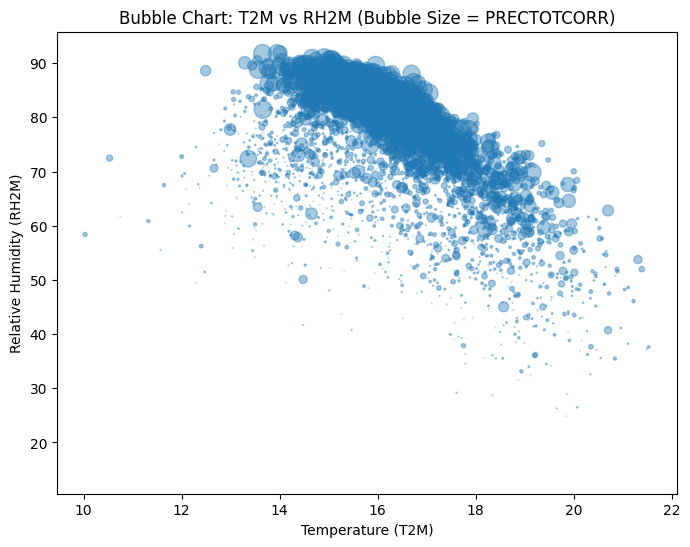

In [25]:
plt.figure(figsize=(8,6))

# scale bubble sizes (important so plot is readable)
sizes = np.clip(df["PRECTOTCORR"], 0, np.percentile(df["PRECTOTCORR"], 95))

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=sizes * 10,   # scaling factor for visibility
    alpha=0.4
)

plt.title("Bubble Chart: T2M vs RH2M (Bubble Size = PRECTOTCORR)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")

plt.show()